# Predicting Airline Passenger Satisfaction Using Machine Learning

## Problem Statement
#### The airline industry relies heavily on customer satisfaction for loyalty, repeat business, and competitive advantage. The goal of this project is to build a machine learning model that predicts whether a passenger is Satisfied or Neutral/Dissatisfied based on demographic information, travel details, delays, and service-related ratings.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler #, OneHotEncoder
#from sklearn.compose import ColumnTransformer
#from sklearn.pipeline import Pipeline
#from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score


## Load Dataset

In [2]:
df_airline = pd.read_csv(r'C:\Users\DELL\Desktop\Learnbay_project\DS-DATA.csv')

In [3]:
df_airline

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4,...,4,4,5,3,3,4,5,3,5,Satisfied


## Data Understanding

In [4]:
df_airline.shape

(129880, 24)

In [5]:
df_airline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  object 
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

##### 1. Dataset contains 129,880 rows and 24 columns.
##### 2. ID is only an identifier and not useful for prediction.
##### 3. Flight Distance needs datatype correction.
##### 4. Arrival Delay has missing values.

## Data Cleaning

In [6]:
df_airline.drop(['ID'],axis = 1, inplace=True)

In [7]:
df_airline.describe(percentiles=[0.01,0.1,0.25,0.5,0.75,0.9,0.99]).T

,count,mean,std,min,1%,10%,25%,50%,75%,90%,99%,max
Age,129880.0,39.427957,15.119360,7.0,8.0,20.0,27.0,40.0,51.0,59.0,70.0,85.0
Departure Delay,129880.0,14.713713,38.071126,0.0,0.0,0.0,0.0,0.0,12.0,44.0,180.0,1592.0
Arrival Delay,129487.0,15.091129,38.465650,0.0,0.0,0.0,0.0,0.0,13.0,44.0,182.0,1584.0
Departure and Arrival Time Convenience,129880.0,3.057599,1.526741,0.0,0.0,1.0,2.0,3.0,4.0,5.0,5.0,5.0
Ease of Online Booking,129880.0,2.756876,1.401740,0.0,0.0,1.0,2.0,3.0,4.0,5.0,5.0,5.0
Check-in Service,129880.0,3.306267,1.266185,0.0,1.0,1.0,3.0,3.0,4.0,5.0,5.0,5.0
Online Boarding,129880.0,3.252633,1.350719,0.0,0.0,1.0,2.0,3.0,4.0,5.0,5.0,5.0
Gate Location,129880.0,2.976925,1.278520,0.0,1.0,1.0,2.0,3.0,4.0,5.0,5.0,5.0
On-board Service,129880.0,3.383023,1.287099,0.0,1.0,1.0,2.0,4.0,4.0,5.0,5.0,5.0
Seat Comfort,129880.0,3.441361,1.319289,0.0,1.0,1.0,2.0,4.0,5.0,5.0,5.0,5.0


In [8]:
df_airline["Flight Distance"] = (
    df_airline["Flight Distance"]
    .astype(str)
    .str.replace(r"[^0-9.]", "", regex=True)
)

df_airline["Flight Distance"] = pd.to_numeric(
    df_airline["Flight Distance"],
    errors="coerce"
)

In [9]:
df_airline["Flight Distance"] = df_airline["Flight Distance"].fillna(
    df_airline["Flight Distance"].median()
)

## Missing Values and Duplicates

In [10]:
pd.DataFrame({'Column' : df_airline.columns, 'Count' : df_airline.isna().sum().values, '%' :df_airline.isnull().sum().values/df_airline.shape[0]*100})


,Column,Count,%
0,Gender,0,0.000000
1,Age,0,0.000000
2,Customer Type,0,0.000000
3,Type of Travel,0,0.000000
4,Class,0,0.000000
5,Flight Distance,0,0.000000
6,Departure Delay,0,0.000000
7,Arrival Delay,393,0.302587
8,Departure and Arrival Time Convenience,0,0.000000
9,Ease of Online Booking,0,0.000000


##### Arrival Delay has 393 null values of float type

In [11]:
df_airline.duplicated().sum()

np.int64(0)

## Target Variable Preparation

In [12]:
df_airline['Satisfaction'].value_counts()

Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64

## Exploratory Data Analysis

In [13]:
numeric_cols = df_airline.select_dtypes('number')
categorical_cols = df_airline.select_dtypes('object')
numeric_cols.head()


,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
0,48,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5
1,35,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5
2,41,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3
3,50,1905,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5
4,49,3470,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3


In [14]:
categorical_cols.head()

,Gender,Customer Type,Type of Travel,Class,Satisfaction
0,Male,First-time,Business,Business,Neutral or Dissatisfied
1,Female,Returning,Business,Business,Satisfied
2,Male,Returning,Business,Business,Satisfied
3,Male,Returning,Business,Business,Satisfied
4,Female,Returning,Business,Business,Satisfied


In [15]:
import matplotlib.pyplot as plt

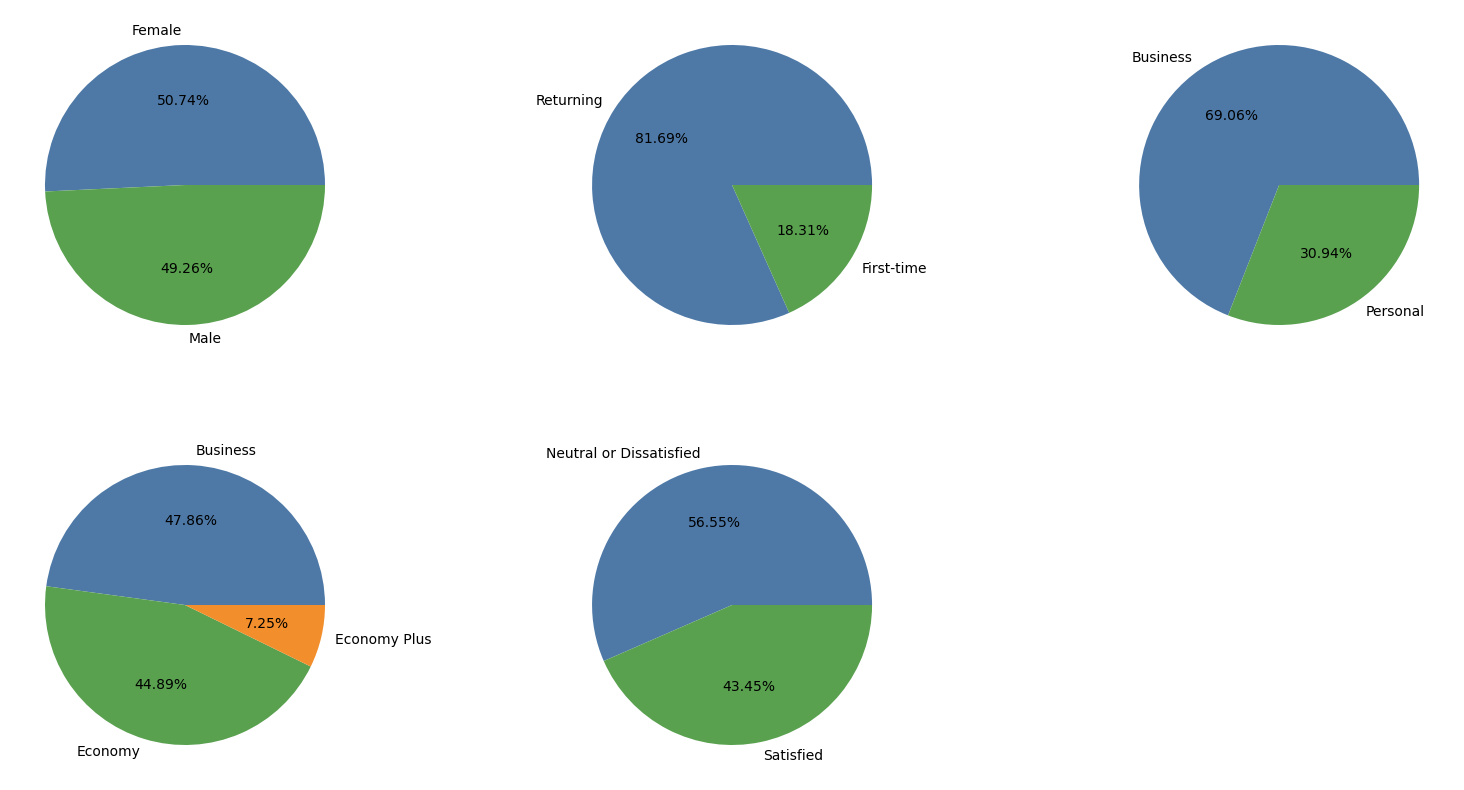

In [16]:
plt.figure(figsize=(20,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2,3,i+1)
    plt.pie(categorical_cols[col].value_counts(), labels = categorical_cols[col].value_counts().keys(),autopct='%0.2F%%',colors = ['#4E79A7', '#59A14F','#F28E2B'])
    

### Redefine target column

In [17]:
df_airline["Satisfaction"] = df_airline["Satisfaction"].str.strip()

df_airline["Satisfaction_Target"] = df_airline["Satisfaction"].map({
    "Satisfied": 1,
    "Neutral or Dissatisfied": 0
})
categorical_cols.drop(['Satisfaction'], axis = 1, inplace = True)

In [18]:
categorical_cols.head()

,Gender,Customer Type,Type of Travel,Class
0,Male,First-time,Business,Business
1,Female,Returning,Business,Business
2,Male,Returning,Business,Business
3,Male,Returning,Business,Business
4,Female,Returning,Business,Business


### Bivariate analysis of categorical columns

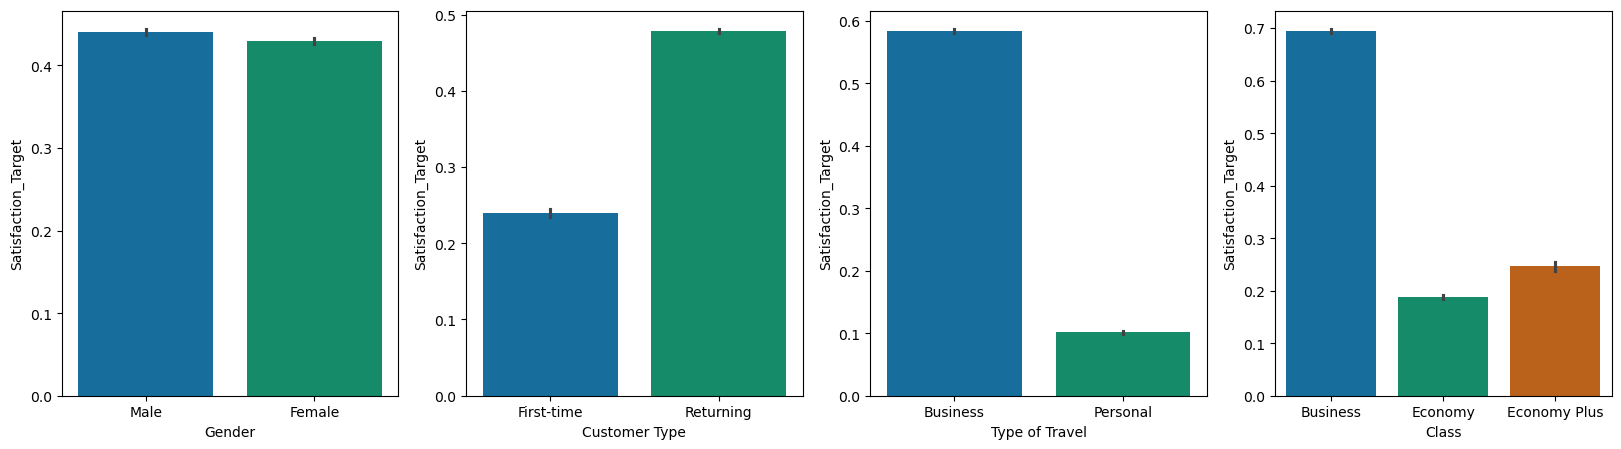

In [19]:
import seaborn as sns
plt.figure(figsize=(20,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,4, i+1)
    sns.barplot(data = df_airline, x = col, y ='Satisfaction_Target',palette='colorblind6')

##### In Gender feature there is almost equal chances for both male and female in prediction. So it doesn't influence much on predictions

### Numerical features having value counts less than 10 are considered as categorical features.

In [20]:
categorical_cols_count = [col for col in numeric_cols if df_airline[col].nunique() < 10]
categorical_cols_count

['Departure and Arrival Time Convenience',
 'Ease of Online Booking',
 'Check-in Service',
 'Online Boarding',
 'Gate Location',
 'On-board Service',
 'Seat Comfort',
 'Leg Room Service',
 'Cleanliness',
 'Food and Drink',
 'In-flight Service',
 'In-flight Wifi Service',
 'In-flight Entertainment',
 'Baggage Handling']

In [21]:
numeric_cols= [col for col in numeric_cols if df_airline[col].nunique() > 10]
numeric_cols

['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay']

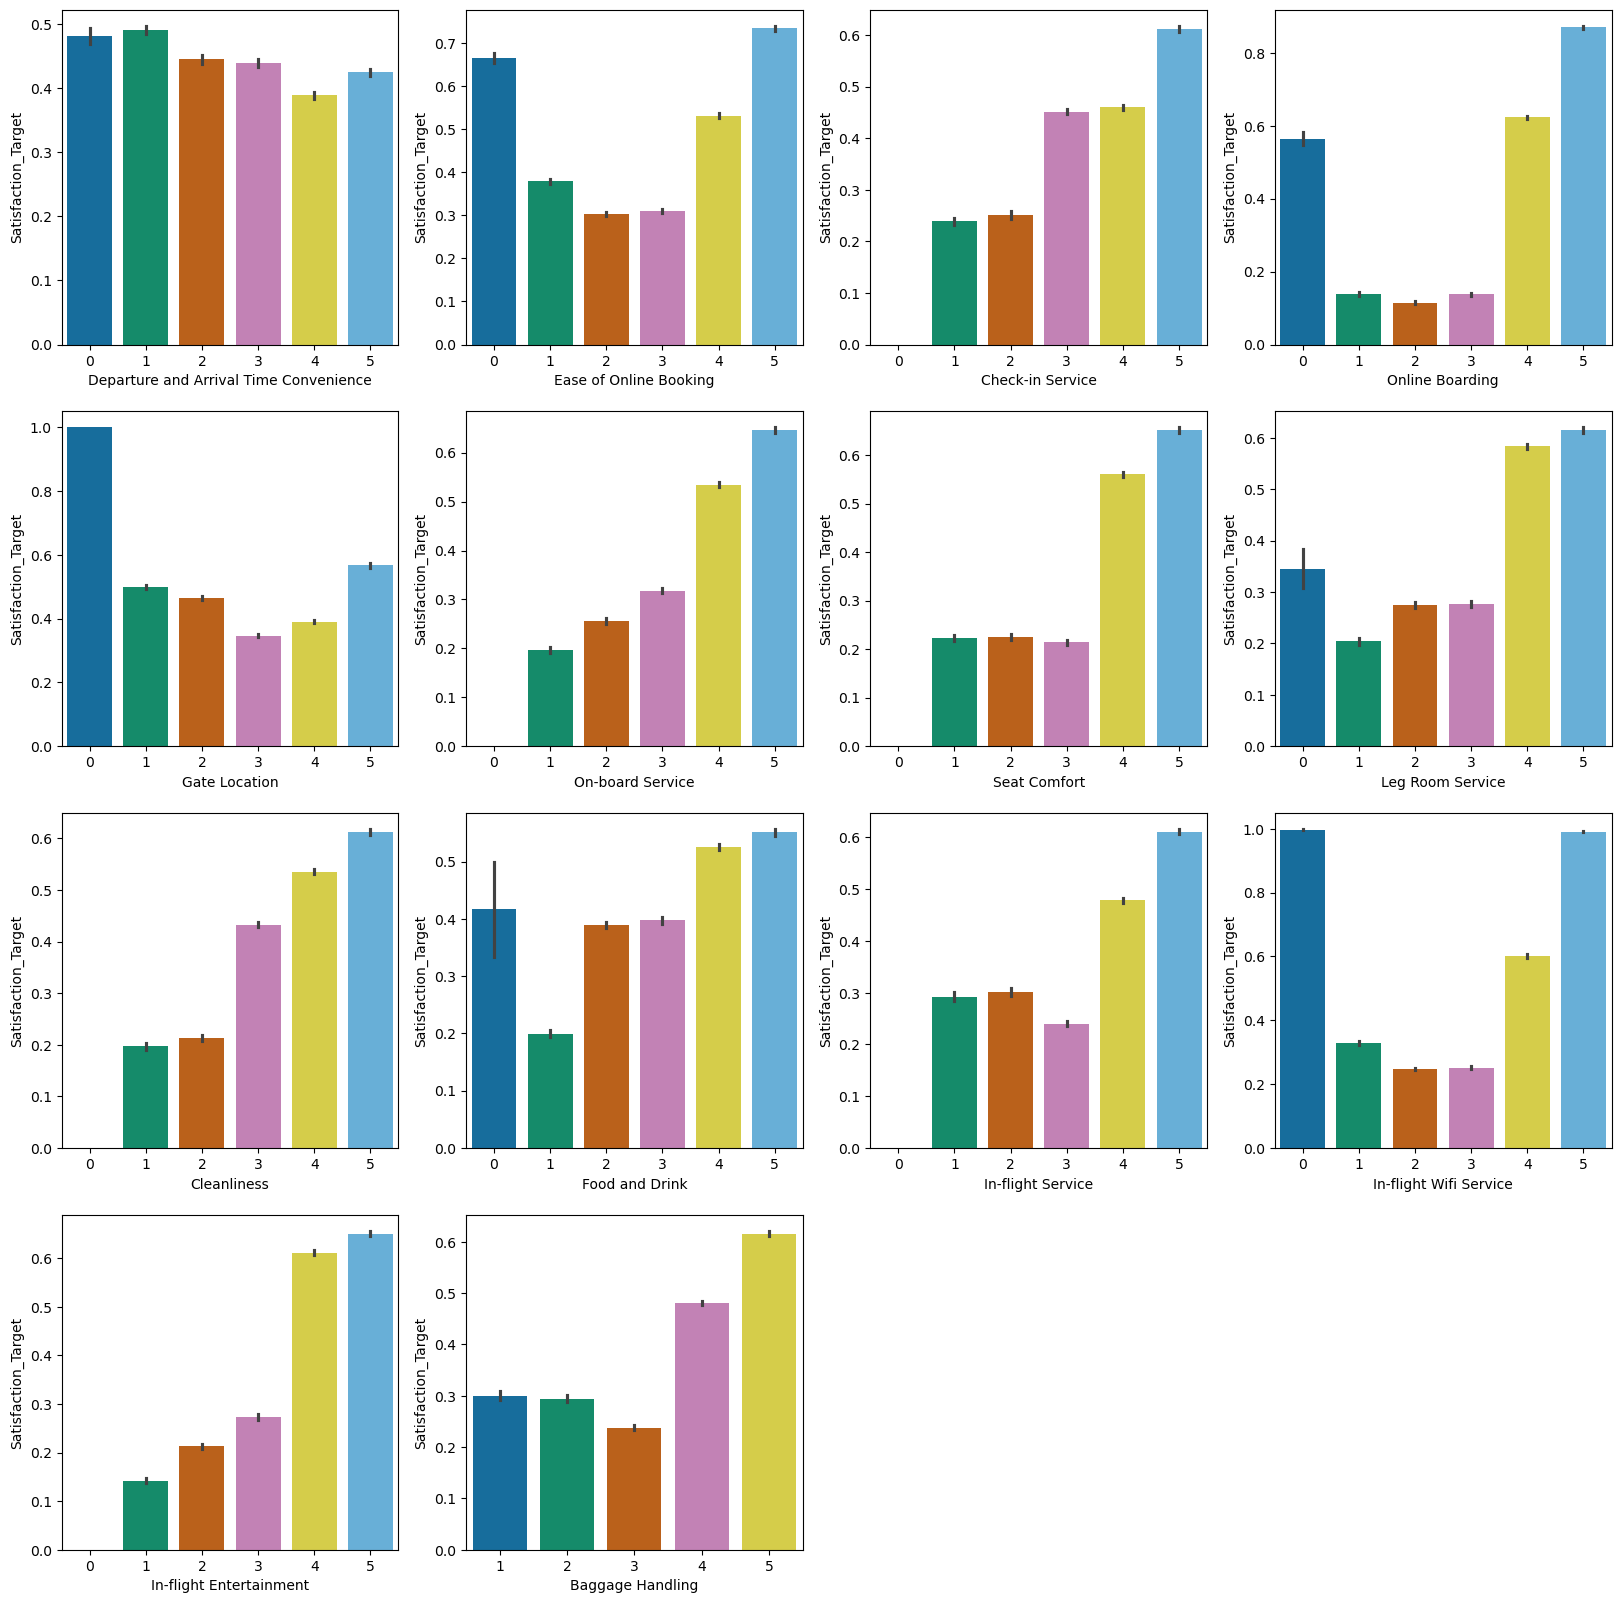

In [22]:
plt.figure(figsize=(20,20))
for i,col in enumerate(categorical_cols_count):
    plt.subplot(4,4,i+1)
    sns.barplot(data=df_airline, x=col, y='Satisfaction_Target', palette='colorblind6')

##### In all the features there is variation in values w.r.t target variable, so all the features plays importance in predictions.

### Pearson's correlation coefficient

<Axes: >

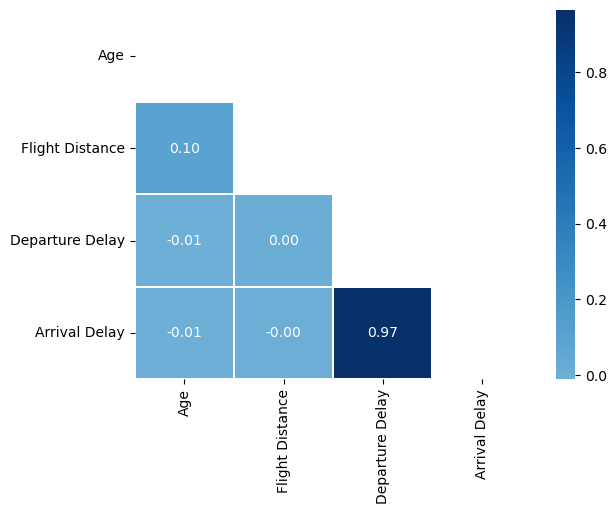

In [23]:
numeric_cols_corr_matrix = df_airline[numeric_cols].corr()
sns.heatmap(numeric_cols_corr_matrix, annot = True, linewidths=0.3, mask=np.triu(numeric_cols_corr_matrix),cmap='Blues', center=0, fmt='.2f')

##### 1. Departure Delay and Arrival Delay are highly correlated.
##### 2. One of them could be dropped.

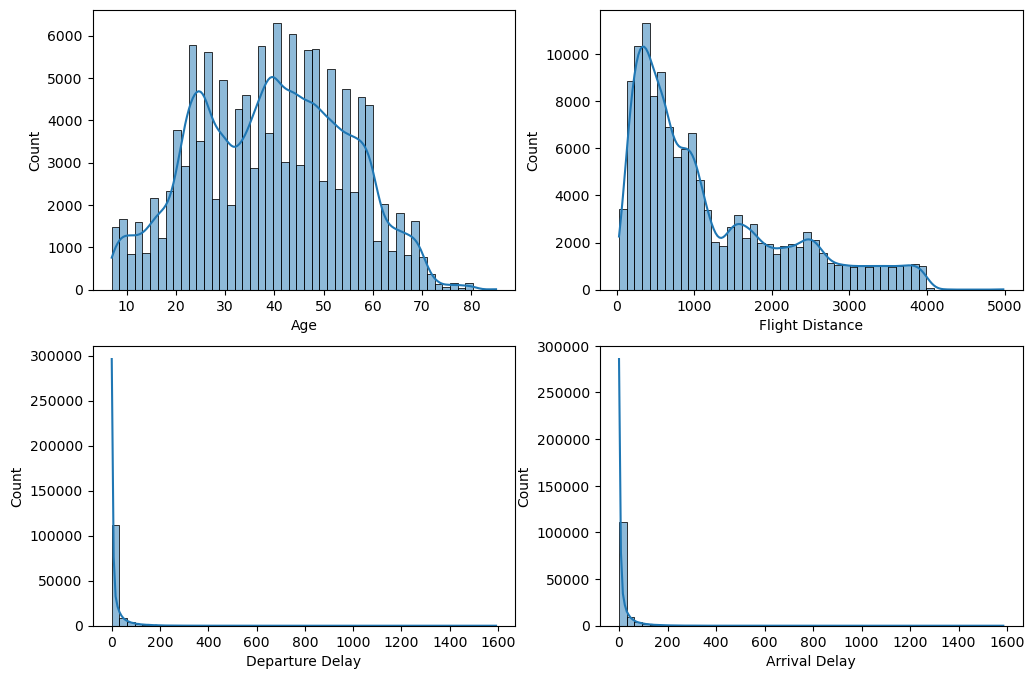

In [24]:
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2,2, i+1)
    sns.histplot(df_airline[col],bins=50,kde=True,palette='Set2')

##### Departure Delay and Arrival Delay are highly right skewed.

In [25]:
numeric_cols.remove('Arrival Delay')

##### 1. There is high correlation between Departure Delay and Arrival Delay.
##### 2. Also there are missing values in it.
##### 3. So, Arrival Delay is dropped.

## Feature Encoding

In [26]:
categorical_encoded = pd.get_dummies(categorical_cols, drop_first = True, dtype = int)
categorical_encoded.head()

,Gender_Male,Customer Type_Returning,Type of Travel_Personal,Class_Economy,Class_Economy Plus
0,1,0,0,0,0
1,0,1,0,0,0
2,1,1,0,0,0
3,1,1,0,0,0
4,0,1,0,0,0


## Concat Columns

In [27]:
df_numeric_col = df_airline[numeric_cols]
df_categorical_col = df_airline[categorical_cols_count]

In [28]:
df_concat = pd.concat([df_numeric_col, df_categorical_col, categorical_encoded, df_airline['Satisfaction_Target']],axis=1)

In [29]:
df_concat.head()

,Age,Flight Distance,Departure Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,...,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Gender_Male,Customer Type_Returning,Type of Travel_Personal,Class_Economy,Class_Economy Plus,Satisfaction_Target
0,48,821,2,3,3,4,3,3,3,5,...,5,3,5,5,1,0,0,0,0,0
1,35,821,26,2,2,3,5,2,5,4,...,5,2,5,5,0,1,0,0,0,1
2,41,853,0,4,4,4,5,4,3,5,...,3,4,3,3,1,1,0,0,0,1
3,50,1905,0,2,2,3,4,2,5,5,...,5,2,5,5,1,1,0,0,0,1
4,49,3470,0,3,3,3,5,3,3,4,...,3,3,3,3,0,1,0,0,0,1


## Outlier Treatment

In [30]:
outlier = df_concat['Departure Delay'].quantile(0.99)
df_concat = df_concat[df_concat['Departure Delay'] <= outlier]


##### Only those data points retained which are within 99 percentile of Departure Delay

## Train-Test Split

In [31]:
x = df_concat.drop(['Satisfaction_Target'], axis =1)
y = df_concat['Satisfaction_Target']

In [32]:
x_train, x_test, y_train, y_test =  train_test_split(x, y, test_size=0.2, random_state=42)

## Feature Scaling

#### Only scale continuous numeric features for Logistic Regression.

In [33]:
scaler = StandardScaler()

x_train_scaled = x_train.copy()
x_test_scaled  = x_test.copy()

x_train_scaled[list(df_numeric_col)] = scaler.fit_transform(x_train[list(df_numeric_col)])
x_test_scaled[list(df_numeric_col)]  = scaler.transform(x_test[list(df_numeric_col)])

In [34]:
print(df_concat.shape)
print(x_train.shape)
print(x_test.shape)

(128590, 23)
(102872, 22)
(25718, 22)


## Model Building

### Logistic Regression

In [35]:
log_reg = LogisticRegression()
log_reg.fit(x_train_scaled,y_train)

LogisticRegression()

## Evaluation Function

In [36]:
def result_evaluation(model, x_train, x_test, y_train, y_test):
    y_pred = model.predict(x_train)
    y_pred1 = model.predict(x_test)

    print('\n-----------Train data results--------')
    print('=======================================')
    accuracy = accuracy_score(y_train, y_pred)
    print('\n Accuracy:', accuracy)
    accuracy = accuracy_score(y_train, y_pred)
    print('\n Confusion Matrix:')
    display(pd.DataFrame(confusion_matrix(y_train, y_pred)))
    print('\n Classification Matrix:')
    display(pd.DataFrame(classification_report(y_train,y_pred,output_dict=True)))

    print('\n-----------Test data results---------')
    print('=======================================')
    accuracy = accuracy_score(y_test, y_pred1)
    print('\n Accuracy:', accuracy)
    accuracy = accuracy_score(y_test, y_pred1)
    print('\n Confusion Matrix:')
    display(pd.DataFrame(confusion_matrix(y_test, y_pred1)))
    print('\n Classification Matrix:')
    display(pd.DataFrame(classification_report(y_test, y_pred1,output_dict=True)))


    

#### Evaluation

In [37]:
result_evaluation(log_reg, x_train_scaled, x_test_scaled, y_train, y_test)


-----------Train data results--------

 Accuracy: 0.8751652539077689

 Confusion Matrix:


,0,1
0,52463,5564
1,7278,37567



 Classification Matrix:


,0,1,accuracy,macro avg,weighted avg
precision,0.878174,0.870998,0.875165,0.874586,0.875046
recall,0.904114,0.837708,0.875165,0.870911,0.875165
f1-score,0.890955,0.854028,0.875165,0.872492,0.874858
support,58027.000000,44845.000000,0.875165,102872.000000,102872.000000



-----------Test data results---------

 Accuracy: 0.8725017497472587

 Confusion Matrix:


,0,1
0,13201,1397
1,1882,9238



 Classification Matrix:


,0,1,accuracy,macro avg,weighted avg
precision,0.875224,0.868641,0.872502,0.871933,0.872378
recall,0.904302,0.830755,0.872502,0.867529,0.872502
f1-score,0.889525,0.849276,0.872502,0.869401,0.872122
support,14598.000000,11120.000000,0.872502,25718.000000,25718.000000


### Decision Tree

In [38]:
decision_tree = DecisionTreeClassifier(
        criterion = 'gini',
        max_depth = 12,
        min_samples_split = 20,
        min_samples_leaf = 10,
        class_weight = 'balanced',
        )
decision_tree.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=10, min_samples_split=20)

#### Evaluation

In [39]:
result_evaluation(decision_tree, x_train, x_test, y_train, y_test)


-----------Train data results--------

 Accuracy: 0.9561979936231433

 Confusion Matrix:


,0,1
0,56009,2018
1,2488,42357



 Classification Matrix:


,0,1,accuracy,macro avg,weighted avg
precision,0.957468,0.954524,0.956198,0.955996,0.956185
recall,0.965223,0.944520,0.956198,0.954872,0.956198
f1-score,0.961330,0.949496,0.956198,0.955413,0.956171
support,58027.000000,44845.000000,0.956198,102872.000000,102872.000000



-----------Test data results---------

 Accuracy: 0.947663115327786

 Confusion Matrix:


,0,1
0,13994,604
1,742,10378



 Classification Matrix:


,0,1,accuracy,macro avg,weighted avg
precision,0.949647,0.945001,0.947663,0.947324,0.947638
recall,0.958624,0.933273,0.947663,0.945949,0.947663
f1-score,0.954115,0.939101,0.947663,0.946608,0.947623
support,14598.000000,11120.000000,0.947663,25718.000000,25718.000000


### Random Forest 

In [40]:
random_forest = RandomForestClassifier(
        n_estimators = 200,
        max_depth = 18,
        min_samples_split = 10,
        min_samples_leaf = 5,
        class_weight = 'balanced',
        n_jobs = -1
        )

random_forest.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=18,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1)

#### Evaluation

In [41]:
result_evaluation(random_forest, x_train, x_test, y_train, y_test)


-----------Train data results--------

 Accuracy: 0.9697488140601913

 Confusion Matrix:


,0,1
0,56876,1151
1,1961,42884



 Classification Matrix:


,0,1,accuracy,macro avg,weighted avg
precision,0.966671,0.973862,0.969749,0.970266,0.969805
recall,0.980164,0.956272,0.969749,0.968218,0.969749
f1-score,0.973371,0.964986,0.969749,0.969179,0.969716
support,58027.000000,44845.000000,0.969749,102872.000000,102872.000000



-----------Test data results---------

 Accuracy: 0.9577338828835835

 Confusion Matrix:


,0,1
0,14141,457
1,630,10490



 Classification Matrix:


,0,1,accuracy,macro avg,weighted avg
precision,0.957349,0.958253,0.957734,0.957801,0.957740
recall,0.968694,0.943345,0.957734,0.956020,0.957734
f1-score,0.962988,0.950741,0.957734,0.956865,0.957693
support,14598.000000,11120.000000,0.957734,25718.000000,25718.000000


## Cross Validation

In [42]:
log_reg_cv_val = cross_val_score(log_reg, x, y, scoring='accuracy')
print("Logistic Regression CV Accuracy:", log_reg_cv_val.mean())

decision_tree_cv_val = cross_val_score(decision_tree, x, y, scoring='accuracy')
print("Decision Tree CV Accuracy:", decision_tree_cv_val.mean())

random_forest_cv_val = cross_val_score(random_forest, x, y, scoring='accuracy')
print("Random Forest CV Accuracy:", random_forest_cv_val.mean())


Logistic Regression CV Accuracy: 0.8239054358814839
Decision Tree CV Accuracy: 0.9462944241387354
Random Forest CV Accuracy: 0.9559141457345051


## ROC-AUC

In [43]:
log_reg_auc = roc_auc_score(y_test, log_reg.predict_proba(x_test_scaled)[:, 1])
print("Logistic Regression ROC-AUC:", log_reg_auc)

decision_tree_auc = roc_auc_score(y_test, decision_tree.predict_proba(x_test)[:, 1])
print("Decision Tree ROC-AUC:", decision_tree_auc)

random_forest_auc = roc_auc_score(y_test, random_forest.predict_proba(x_test)[:, 1])
print("Random Forest ROC-AUC:", random_forest_auc)

Logistic Regression ROC-AUC: 0.9246933833943942
Decision Tree ROC-AUC: 0.9871733008168064
Random Forest ROC-AUC: 0.9931271197591865


In [ ]:
Find first non-repeating character 
Input: "aabbcddde" 
Output: c

In [2]:
def non_repeating(s):
    valid={}
    for ch in s:
        if ch not in valid:
            valid[ch]=1
        else:
            valid[ch]+=1
            if 
        

if __name__=="__main__":
    s="aabbcddde"
    non_repeating(s)
        
        
        

TypeError: object of type 'int' has no len()